In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
df = pd.read_csv(r"C:\Users\SHREE HARINI\Downloads\social_media_dataset_with_null_duplicates_outliers.csv")

print(df.head())
print(df.shape)

   Post_ID   Platform     Likes  Comments  Shares  Views Sentiment
0        1  Instagram     304.0     384.0      71  17049  Positive
1        2   Facebook     939.0     351.0     190  36741  Positive
2        3    YouTube  250000.0      21.0       8   7140  Positive
3        4   Facebook    4239.0     313.0       7  37781  Positive
4        5    YouTube    3536.0     117.0     115  39618   Neutral
(53, 7)


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Post_ID    53 non-null     int64  
 1   Platform   52 non-null     object 
 2   Likes      52 non-null     float64
 3   Comments   52 non-null     float64
 4   Shares     53 non-null     int64  
 5   Views      53 non-null     int64  
 6   Sentiment  52 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ KB
None


In [18]:
print(df.describe())

         Post_ID          Likes     Comments      Shares           Views
count  53.000000      52.000000    52.000000   53.000000       53.000000
mean   25.018868    7544.961538   345.115385   96.584906    45828.415094
std    14.386814   34306.916476   674.785214   61.786367   134280.320211
min     1.000000     220.000000     8.000000    5.000000     4665.000000
25%    13.000000    1893.750000   116.000000   51.000000    16491.000000
50%    25.000000    3038.500000   276.500000   76.000000    31318.000000
75%    37.000000    3978.750000   385.250000  151.000000    38182.000000
max    50.000000  250000.000000  5000.000000  200.000000  1000000.000000


In [19]:
print(df.isnull())

    Post_ID  Platform  Likes  Comments  Shares  Views  Sentiment
0     False     False  False     False   False  False      False
1     False     False  False     False   False  False      False
2     False     False  False     False   False  False      False
3     False     False  False     False   False  False      False
4     False     False  False     False   False  False      False
5     False     False   True     False   False  False      False
6     False     False  False     False   False  False      False
7     False     False  False     False   False  False      False
8     False     False  False     False   False  False      False
9     False     False  False     False   False  False      False
10    False     False  False     False   False  False      False
11    False     False  False     False   False  False      False
12    False      True  False     False   False  False      False
13    False     False  False     False   False  False      False
14    False     False  Fa

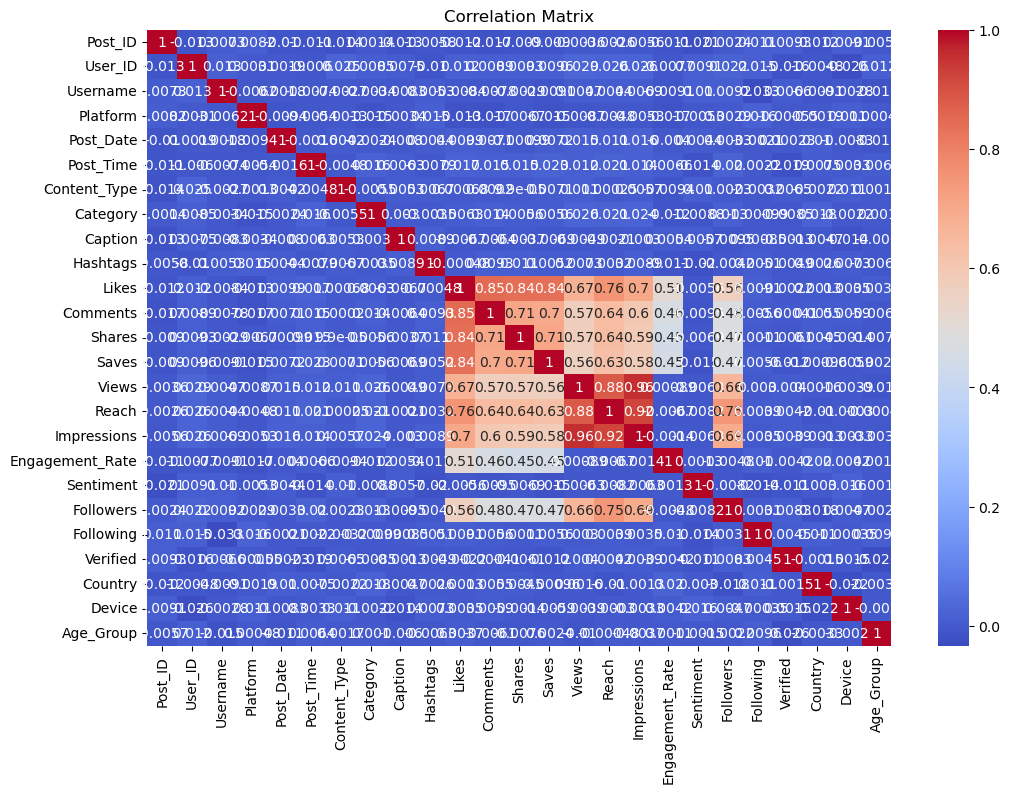

In [20]:
numeric_cols = sample_df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
df = df.dropna()
print(df)

    Post_ID   Platform     Likes  Comments  Shares    Views Sentiment
0         1  Instagram     304.0     384.0      71    17049  Positive
1         2   Facebook     939.0     351.0     190    36741  Positive
2         3    YouTube  250000.0      21.0       8     7140  Positive
3         4   Facebook    4239.0     313.0       7    37781  Positive
4         5    YouTube    3536.0     117.0     115    39618   Neutral
6         7   Facebook    1863.0     495.0     196    23059  Positive
7         8  Instagram    3212.0      54.0      92    23541  Negative
8         9    Twitter     455.0     378.0     118    36142  Positive
9        10   LinkedIn     745.0     287.0      76    42198  Negative
10       11    Twitter    4829.0     103.0     181     5558  Positive
11       12   Facebook    2470.0      45.0      60     7619   Neutral
13       14    Twitter    1816.0     348.0      69    46994  Negative
14       15  Instagram    1501.0     278.0     187    17043  Positive
15       16   Linked

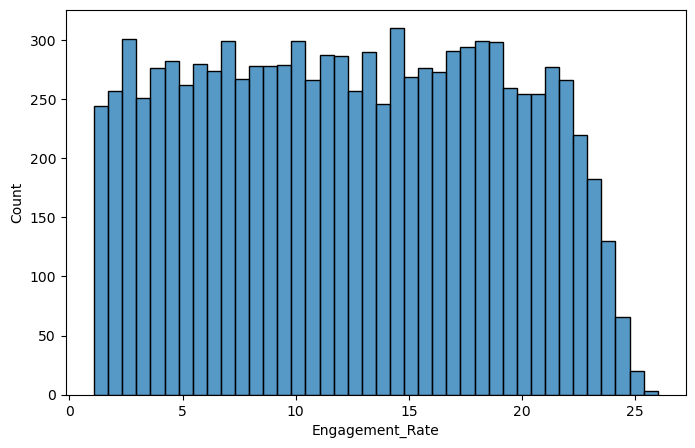

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(sample_df["Engagement_Rate"], bins=40)
plt.show()

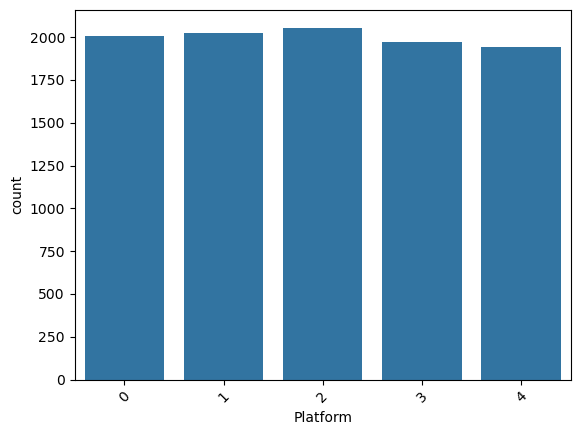

In [24]:
sns.countplot(x="Platform", data=sample_df)
plt.xticks(rotation=45)
plt.show()

In [28]:

df = df.drop_duplicates()


from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical = ["Platform", "Sentiment"]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   Post_ID  Platform     Likes  Comments  Shares  Views  Sentiment
0        1         1     304.0     384.0      71  17049          2
1        2         0     939.0     351.0     190  36741          2
2        3         4  250000.0      21.0       8   7140          2
3        4         0    4239.0     313.0       7  37781          2
4        5         4    3536.0     117.0     115  39618          1


C:\Users\SHREE HARINI\AppData\Local\Temp\ipykernel_11512\2790668386.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\SHREE HARINI\AppData\Local\Temp\ipykernel_11512\2790668386.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])


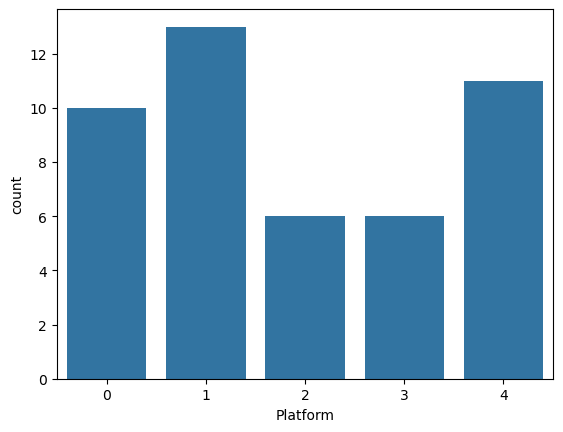

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Platform", data=df)
plt.show()



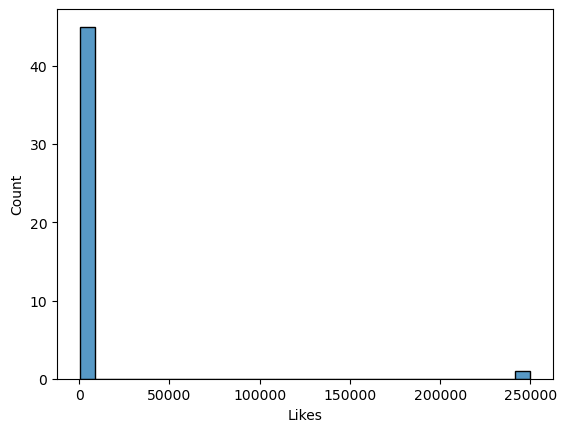

In [31]:
sns.histplot(df["Likes"], bins=30)
plt.show()


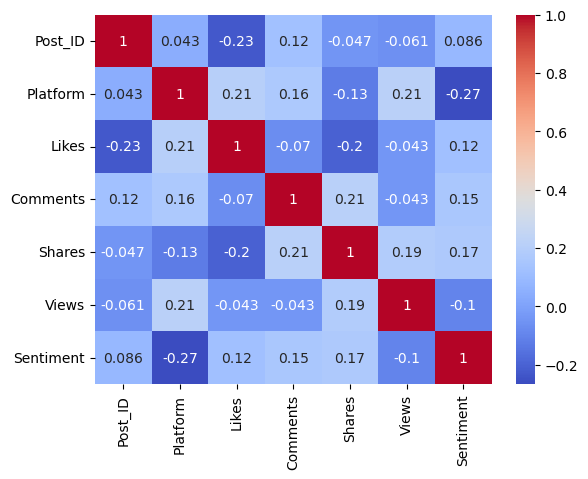

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

C:\Users\SHREE HARINI\AppData\Local\Temp\ipykernel_11512\523159258.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Platform"] = encoder.fit_transform(df["Platform"])
C:\Users\SHREE HARINI\AppData\Local\Temp\ipykernel_11512\523159258.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sentiment"] = encoder.fit_transform(df["Sentiment"])


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 19561.31
RMSE : 40099.67852317846
R2 Score : -732.7500379312155


In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
3     Shares    0.435930
2   Comments    0.220547
0    Post_ID    0.196712
4      Views    0.107214
1   Platform    0.025707
5  Sentiment    0.013890


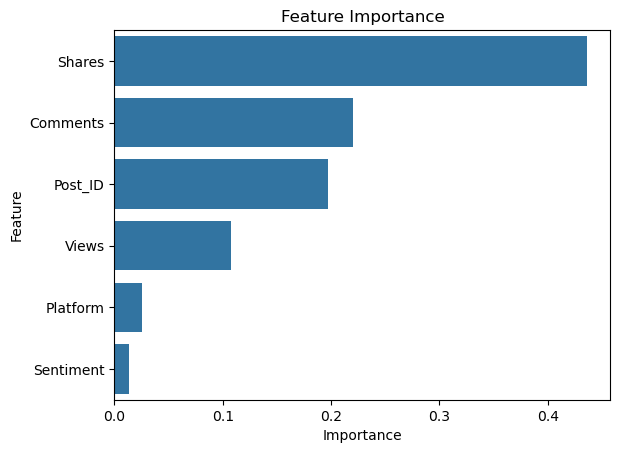

In [42]:
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [43]:
new_post = [[101, 1, 250, 75, 10000, 2]]

prediction = model.predict(new_post)

print("Predicted Likes:", prediction[0])

Predicted Likes: 2423.27


In [ ]:
#k